# Using the GWE Model to simulate one-dimensional, transient heat transport with thermal conduction and steady advection (Stallman problem)

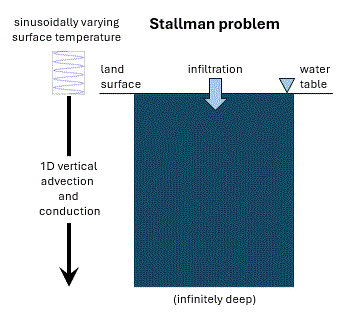

## What this notebook covers

Simulate how heat (thermal energy) moves through the subsurface when the land-surface temperature swings up and down through the seasons. This is the classic **Stallman problem**: a periodic, **sinusoidally** varying temperature is imposed at the top of a vertical soil/aquifer column, water flows steadily downward, and heat is carried into the ground by two processes at once — **conduction** through the water and solid, and **advection** with the moving water. Deeper in the column the temperature signal both **damps** (its swings get smaller) and **lags** (its peaks arrive later); you will compare the simulated temperature profile against Stallman's classic analytical solution.

By the end you will have built a groundwater energy transport (**GWE**) model coupled to a groundwater flow (**GWF**) model, run it, plotted temperature-versus-depth profiles against the analytical solution, reasoned about the time scales of advection and conduction, and reproduced the same result with a groundwater transport (**GWT**) solute model tricked into emulating heat transport.

The first part of this example demonstrates the use of the Groundwater Energy (GWE) Model to simulate one-dimensional, transient thermal-energy (heat) transport in the subsurface in response to a cyclical (sinusoidally varying) land-surface temperature and downward, fully saturated, steady-state groundwater flow. Results are compared with the analytical solution of Stallman (1965, Journal of Geophysical Research), which is valid at long times, after the influence of the initial conditions has decayed away.

The second part of this example explores the analogy between heat transport and solute transport. A GWT solute-transport model is constructed with "surrogate" parameter values that allow it to emulate heat transport in this example.

## Set up

The model parameters and all the machinery to build, run, and plot this problem live in the paired helper module `mf6_gwe_stallman.py`, so this notebook can stay focused on the exercises. Import it and create a `StallmanProblem` with the base-case parameters. Every parameter is an attribute of `prob` (for example `prob.porosity`, `prob.darcy_flux`, `prob.alpha_b`), so you can inspect or change any of them.

In [ ]:
import mf6_gwe_stallman
from IPython.display import HTML
from mf6_notebook_helpers import seconds_per_year

# The parameter values and the model-building code are in mf6_gwe_stallman.py.
prob = mf6_gwe_stallman.StallmanProblem()

## Build and write the simulation

Build the coupled flow-and-energy simulation and write its input files. `prob.build()` constructs the groundwater flow (**GWF**) model, the groundwater energy transport (**GWE**) model, and the GWF-GWE exchange that links them; `prob.write()` writes the MODFLOW 6 input files to `prob.sim_ws`.

In [ ]:
prob.build()
prob.write()

## Exercise A -- Time scales

__For definitions of the parameters you encounter below, you can refer to the parameter attributes on the `prob` object (they are defined in `mf6_gwe_stallman.py`).__

__A1.__ Run the simulation and plot the temperature profile using the __next two__ notebook cells below as they are. The plot will compare the GWE model results with the analytical solution after one surface-temperature cycle (one year).  What's the main reason we shouldn't necessarily expect these model results to agree with the analytical solution very well? (Partial spoiler in part __A2__.)

In [ ]:
# Run the base simulation (GWF + GWE). This takes a few minutes; you only
# need to run it once for Exercise A.
prob.run()

In [ ]:
# Plot the temperature profile after ktau surface-temperature cycles against
# Stallman's analytical solution. ktau may be fractional (e.g. 1.5) and must be
# no greater than prob.ntau (6). Rerun this cell with different ktau for A2.
prob.plot(ktau=1.0)

**What to look for.** The black dashed line is Stallman's analytical solution and the blue circles are the GWE model; temperature is on the x-axis and depth on the y-axis (0 at land surface, increasing downward). Two features define the Stallman problem: the temperature swing **damps** with depth (the profile narrows toward the ambient temperature as you go down) and it is **phase-shifted** (the deeper you look, the more the signal lags the surface). Near the surface the model and the analytical solution overlap closely; deeper down, after only one cycle, they diverge because the analytical solution assumes the influence of the initial conditions has washed out — which has not yet happened at depth. The exercises below explore how many cycles it takes for the two to agree all the way down.


__A2.__ Rerun the previous notebook cell (the one that extracts and plots results) with different values of ktau, the number of cycles (years) at which the results are plotted. By trial and error, find the number of cycles (years) at which the simulation results __match the analytical solution pretty well down to 60 m depth__ but don't match so well below that.  (No need to be too precise, and trying ktau values in increments of 0.5 years in good enough for our purposes.) This is how long it takes the effect of the surface-temperature variation to essentially fully penetrate to 60 m depth by a combination of advection in the water and conduction in the water and the solid aquifer material, and effectively "flush out" the effects of the initial conditions to that depth.


__A3.__ Let's compare the result from __A2__ with rough estimates of the times required for a temperature signal at land surface to traverse the top 60 m of the model domain by advection and by conduction. Advection at velocity v traverses a distance L in time
<blockquote>
t_adv = L / v
</blockquote>
and the characteristic time for conduction over a distance L is
<blockquote>
t_cond = L**2 / alpha_b <br>
</blockquote>
where L**2 is L squared and alpha_b is the bulk thermal diffusivity. The advective velocity is related to our specified Darcy flux by
<blockquote>
    v = darcy_flux / porosity <br>
</blockquote>

__The cell below will calculate these times for you.__

Based on these times, which transport mechanism - advection or conduction - is dominant in this problem? (Spoiler in __A4__ below.) This is the process that's primarily controlling penetration of the surface-temperature signal into the subsurface.

In [ ]:
# Calculations for A3
L = 60  # depth of interest (m)
v = prob.darcy_flux / prob.porosity  # linear velocity of flow (m / s)

t_adv = L / v / seconds_per_year  # characteristic time for advection (yr)
t_cond = (
    L**2 / prob.alpha_b / seconds_per_year
)  # characteristic time for conduction (yr)

print("characteristic times from A3 (yr):")
print("    advection ", t_adv)
print("    conduction", t_cond)


__A4.__ How does the characteristic time for the dominant transport mechanism (advection) calculated in __A3__ compare with the penetration time determined in __A2__? Characteristic times are rough estimates based on generic scaling arguments, so we don't necessarily expect exact agreement. That said, we can probably do better. What energy-transport process does that characteristic time from __A3__ fail to take into account? (Spoiler in __A5__ below.)


__A5.__ Sorption of solute onto solid aquifer material effectively slows the rate of solute transport. The factor by which transport is slowed is called the "retardation factor" and is greater than or equal to 1. In heat transport, storage of heat in the solid is analogous to sorption in the sense that heat distributes itself between the water and the solid. In the MODFLOW 6 GWE Model, the water and solid are assumed to be at the same temperature (at thermal equilibrium) at any given point in the model, so heat storage in the solid is analogous to equilibrium sorption.  One can, in fact, define a "thermal retardation factor" by which heat transport is slowed due to storage of heat in the solid. Under the assumptions inherent in this example problem, the thermal retardation factor is

<blockquote>
R_T = 1 + (1 - porosity) * c_rho_w / porosity / c_rho_s <br>
</blockquote>

or, equivalently (and more simply),

<blockquote>
R_T = 1 / porosity / c_rho_ratio <br>
</blockquote>

__The cell below will calculate R_T for you.__

Apply this retardation factor to the estimated characteristic time for the advection, i.e., to effectively slow advection down. Is the estimated characteristic time now closer to the simulated penetration time from __A2__?

In [ ]:
# Calculations for A5
R_T = 1.0 / prob.c_rho_ratio / prob.porosity

print("retardation factor:", R_T)


__A6.__ Replot the temperature profile for ktau = 6, which is the end of the simulation. This should produce decent agreement throughout the model domain.

In [ ]:
prob.plot(ktau=6.0)


## Exercise B -- Faking heat transport with a solute-transport model

To further explore the analogy between heat and solute transport, let's solve this problem using a GWT (solute transport) model instead of a GWE model. We'll do this by manipulating the input to the GWT model to trick it into solving the same equation the GWE model does. The resulting "concentrations" will be the temperature values we want to simulate.

The governing equations solved by the GWE and GWT models (including only the terms relevant to this problem) can be written as

$\left ( 1 + \frac{\left (1 - \theta \right ) \rho_s C_{Ps}}{\theta \rho_w C_{Pw}} \right ) \frac{\partial T}{\partial t} = - v \frac{\partial T}{\partial z} + \frac{\alpha_b}{\theta \left ( \rho C_{P} \right )_{b}} \frac{{\partial}^{2} T}{\partial z^2}$

and

$\left ( 1 + \frac{\rho_b K_d}{\theta} \right ) \frac{\partial C}{\partial t} = - v \frac{\partial C}{\partial z} + D^{mol} \frac{{\partial}^{2} C}{\partial z^2}$

respectively, where

$T$ is temperature

$C$ is concentration, which we want to mimic temperature

$t$ is time

$z$ is elevation

$v$ is advective velocity

$\theta = $ porosity (the variable called "porosity")

$C_{Pw} = $ specific heat of water (the variable called "c_w")

$C_{Ps} = $ specific heat of solid (variable called "c_s")

$\rho_{w} = $ density of water (the variable called "rho_w")

$\rho_{s} = $ density of solid (the variable called "rho_s")

$\alpha_{b} = $ bulk thermal diffusivity (the variable called "alpha_b")

$\rho_{b} = $ bulk density of the aquifer; mass of solid per volume of aquifer

$K_{d} = $ distribution coefficient for linear sorption

$D^{mol} = $ molecular diffusion coefficient

To get the GWT model to solve the same equation for $C$ that the GWE model solves for $T$, we have to choose our GWT parameters such that the coefficients of corresponding terms have the same numerical values. The coefficients of the time-derivative (storage) terms are the retardation factors. To make the retardation factors equal, we need to set $\rho_b$ and $K_d$ such that

$1 + \frac{\rho_b K_d}{\theta} = 1 + \frac{\left (1 - \theta \right ) \rho_s C_{Ps}}{\theta \rho_w C_{Pw}}$

Since it's only the product $\rho_b K_d$ that matters, we're free to set $\rho_{b}$ to its "real-life" value of

$\rho_{b} = \rho_{s} \left ( 1 - \theta \right )$

(where $\rho_{s} = $ rho_s, the solid density), which makes the algebra to work out $K_d$ fairly straightforward. The coefficients of the advection terms already match, all that's left is to match the coefficient of the solute-diffusion term to the coefficient of the thermal-conduction term.

Note that in more complex problems, including those that involve a transient water table, it's not always possible to reproduce GWE heat-transport results using a GWT solute-transport model.

__B1.__ Go ahead and run the notebook cell immediately below, which creates and writes a separate simulation for the GWT model. (We won't plot results just yet.)

In [ ]:
# B1: build and write a separate GWT (solute-transport) simulation that will
# emulate heat transport once you set its surrogate parameters in B2 below.
prob.add_gwt_surrogate()


__B2.__ If you want, you can work out the formulas for the "surrogate" solute-transport parameters that will allow the GWT model to emulate heat transport. Use the formula for $\rho_b$ given earlier. The formula for $K_d$ will follow from the expression given earlier that equates the retardation factors -- it'll just take a little algebra that'll make use of the expression for $\rho_b$ to simplify things. The formula for $D^{mol}$ will be obvious from comparing the solute-diffusion and thermal-conduction terms. If you would rather not work through the algebra, __feel free to copy the formulas for the surrogate parameters from the last cell in this notebook__.

Enter your surrogate parameter formulas in the notebook cell below, then run the cell to update the relevant input files, run the simulation, and plot the results. If your GWT results don't agree with the GWE and analytical results, fix your surrogate parameters and rerun the notebook cell.

In [ ]:
# B2: set the surrogate solute-transport parameters. The values of 1 are
# placeholders - work out the correct formulas (or copy them from the last cell
# of this notebook), then run this cell to update the input files, run the GWT
# model, and plot GWT alongside GWE and the analytical solution.
bulk_density = 1  # surrogate bulk density of the aquifer
distcoef = 1  # surrogate distribution coefficient
diffc = 1  # surrogate diffusion coefficient

prob.run_gwt_surrogate(bulk_density, distcoef, diffc)
prob.plot(ktau=6)

## Exercise C -- Animation and free play

__C1.__ Run the notebook cell below to create and display an animation of the temperature profiles.  Watch the temperature wave rise and fall over time.

__C2.__ If you have time, feel free to play with the simulation parameters. Keep in mind that, depending on what you change, you might need to rerun the notebook from the beginning for your changes to take effect.

In [ ]:
# Create and display an animation of the temperature profiles over all times.
# framestride thins the frames (here every 10th) to speed up generation.
ani = prob.animate(framestride=10)
HTML(ani.to_jshtml())

## STEP B2 SPOILER ALERT

In [ ]:
# Surrogate solute-transport parameters that make the GWT model emulate heat
# transport. Copy these into the B2 cell above and rerun it.
bulk_density = prob.rho_s * (1 - prob.porosity)  # surrogate bulk density
distcoef = prob.c_s / prob.c_rho_w  # surrogate distribution coefficient
diffc = prob.alpha_b / (
    prob.porosity * prob.c_rho_ratio
)  # surrogate diffusion coefficient

## Recap

In this notebook you:

- built a **groundwater energy transport (GWE)** model coupled to a **groundwater flow (GWF)** model to simulate one-dimensional, transient heat transport driven by a sinusoidal surface temperature and steady downward flow — the **Stallman problem**;
- ran the simulation and plotted temperature-versus-depth profiles, comparing the GWE results against Stallman's analytical solution and watching the surface signal **damp** and **lag** with depth;
- reasoned about the competing time scales of advection and conduction, and about how heat storage in the solid **retards** heat transport much as sorption retards a solute;
- reproduced the same temperature profiles with a **groundwater transport (GWT)** solute model by supplying "surrogate" bulk density, distribution coefficient, and diffusion coefficient that make its governing equation identical to the heat-transport equation; and
- animated the full set of temperature profiles through time.